In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Read dataset
df_new = pd.read_csv(r"C:\Users\charulatha\OneDrive\Desktop\Project_Analysis\Nutri_Class_project\Data\cleaned_encoded_food_dataset.csv")

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


X = df_new.drop(columns=["Food_Name_label"])
y = df_new["Food_Name_label"]

# Stratified split (VERY important for imbalanced classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier()


xgb.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [18]:
y_pred1_xgb = xgb.predict(X_train)
y_pred2_xgb = xgb.predict(X_test)


print("XGBoost Train Accuracy:", accuracy_score(y_train, y_pred1_xgb))
print("XGBoost Test Accuracy:", accuracy_score(y_test, y_pred2_xgb))
print(classification_report(y_test, y_pred2_xgb))

XGBoost Train Accuracy: 0.9982841181165204
XGBoost Test Accuracy: 0.9940941739824422
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       295
           1       0.99      0.99      0.99       237
           2       0.98      0.99      0.99       988
           3       1.00      0.99      1.00       893
           4       1.00      1.00      1.00       593
           5       1.00      1.00      1.00       792
           6       0.99      0.99      0.99      1183
           7       0.99      0.99      0.99       197
           8       1.00      0.99      1.00       397
           9       1.00      1.00      1.00       690

    accuracy                           0.99      6265
   macro avg       0.99      0.99      0.99      6265
weighted avg       0.99      0.99      0.99      6265



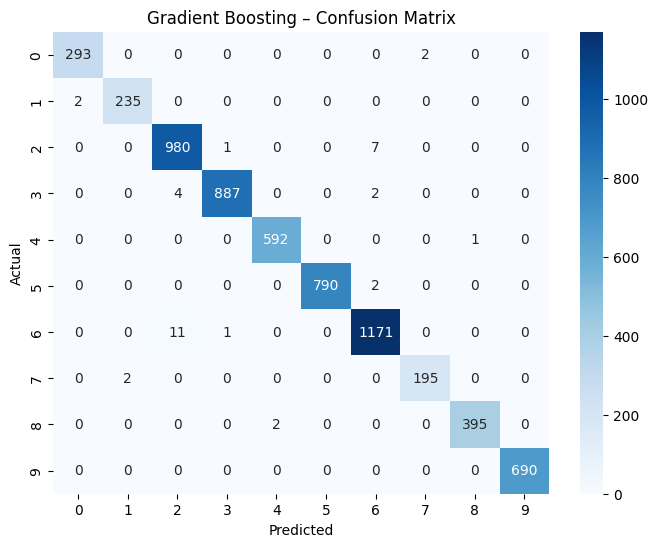

In [17]:
cm = confusion_matrix(y_test, y_pred2_xgb)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot= True, fmt='d', cmap="Blues")
plt.title("Gradient Boosting – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

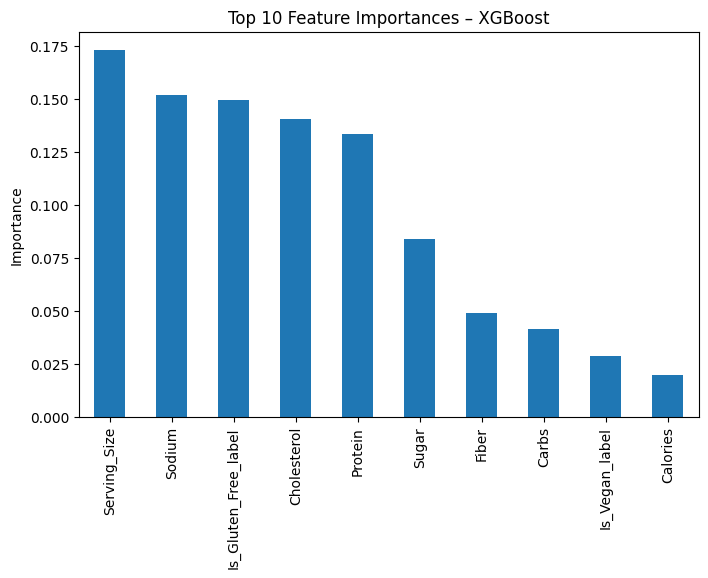

In [16]:
xgb_imp = pd.Series(xgb.feature_importances_, index=X.columns)
xgb_imp.sort_values(ascending=False).head(10).plot(
    kind="bar",
    figsize=(8,5),
    title="Top 10 Feature Importances – XGBoost"
)
plt.ylabel("Importance")
plt.show()